# RetailRocket E-commerce — EDA & Prétraitement

## Objectifs
- Charger et comprendre les données (events, category_tree, item_properties)
- Nettoyer et structurer un dataset prêt pour l’analyse
- Produire des KPI e-commerce (funnel, conversion, tendances)
- Préparer des exports pour dashboard (Tableau ou autre)
- Simuler un A/B test à partir des données (sans source externe)

## Source
RetailRocket E-commerce dataset (Kaggle)


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


In [23]:
#Paths & Chargement des données
DATA_RAW = Path("data/raw")
DATA_PROCESSED = Path("data/processed")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

events_path = DATA_RAW / "events.csv"
cat_path = DATA_RAW / "category_tree.csv"
props1_path = DATA_RAW / "item_properties_part1.csv"
props2_path = DATA_RAW / "item_properties_part2.csv"

events = pd.read_csv('../data/row/events.csv',sep=',')
category_tree = pd.read_csv('../data/row/category_tree.csv',sep=',')
props1 = pd.read_csv('../data/row/item_properties_part1.csv',sep=',')
props2 = pd.read_csv('../data/row/item_properties_part1.csv',sep=',')

print(events.shape, category_tree.shape, props1.shape, props2.shape)
events.head()


(2756101, 5) (1669, 2) (10999999, 4) (10999999, 4)


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [24]:
#Audit  types, valeurs manquantes

def audit_df(df: pd.DataFrame, name: str) -> None:
    print(f"\n--- {name} ---")
    print("Shape:", df.shape)
    display(df.head(3))
    display(df.dtypes)
    missing = df.isna().mean().sort_values(ascending=False)
    display(missing[missing > 0].head(10))

audit_df(events, "events")
audit_df(category_tree, "category_tree")
audit_df(props1, "item_properties_part1")
audit_df(props2, "item_properties_part2")
#Fusion des deux fichiers de propriétés
item_properties = pd.concat([props1, props2], ignore_index=True)
audit_df(item_properties, "item_properties")



--- events ---
Shape: (2756101, 5)


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN


timestamp          int64
visitorid          int64
event             object
itemid             int64
transactionid    float64
dtype: object

transactionid    0.991852
dtype: float64


--- category_tree ---
Shape: (1669, 2)


...

Series([], dtype: float64)


--- item_properties ---
Shape: (21999998, 4)


,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566


timestamp     int64
itemid        int64
property     object
value        object
dtype: object

Series([], dtype: float64)

In [25]:
#Prétraitement events
events_clean = events.copy()

# Convert timestamp (RetailRocket: milliseconds)
events_clean["timestamp"] = pd.to_datetime(events_clean["timestamp"], unit="ms")

# Features temporelles
events_clean["date"] = events_clean["timestamp"].dt.date
events_clean["hour"] = events_clean["timestamp"].dt.hour
events_clean["day_of_week"] = events_clean["timestamp"].dt.day_name()

# Indicateurs funnel
events_clean["is_view"] = (events_clean["event"] == "view").astype(int)
events_clean["is_addtocart"] = (events_clean["event"] == "addtocart").astype(int)
events_clean["is_transaction"] = (events_clean["event"] == "transaction").astype(int)

# Nettoyage minimal
events_clean = events_clean.dropna(subset=["itemid", "visitorid"])
events_clean["itemid"] = events_clean["itemid"].astype(int)
events_clean["visitorid"] = events_clean["visitorid"].astype(int)

events_clean.head()


,timestamp,visitorid,event,itemid,transactionid,date,hour,day_of_week,is_view,is_addtocart,is_transaction
0,2015-06-02 05:02:12.117,257597,view,355908,NaN,2015-06-02,5,Tuesday,1,0,0
1,2015-06-02 05:50:14.164,992329,view,248676,NaN,2015-06-02,5,Tuesday,1,0,0
2,2015-06-02 05:13:19.827,111016,view,318965,NaN,2015-06-02,5,Tuesday,1,0,0
3,2015-06-02 05:12:35.914,483717,view,253185,NaN,2015-06-02,5,Tuesday,1,0,0
4,2015-06-02 05:02:17.106,951259,view,367447,NaN,2015-06-02,5,Tuesday,1,0,0


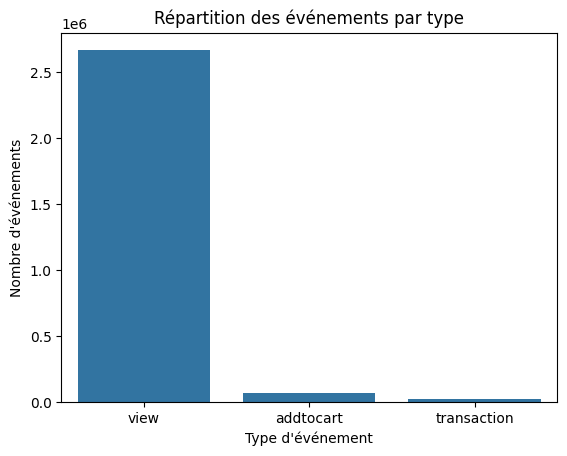

In [26]:
#Visualisation 1 : Répartition des événements
sns.countplot(
    x="event",
    order=["view", "addtocart", "transaction"],
    data=events_clean
)
plt.title("Répartition des événements par type")
plt.xlabel("Type d'événement")
plt.ylabel("Nombre d'événements")
plt.show()

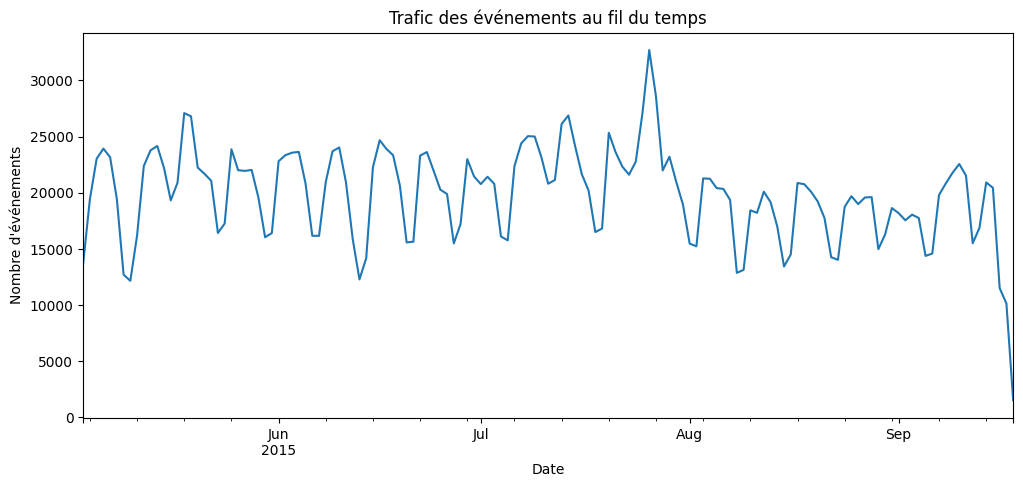

In [27]:
#Visualisation 2 : Trafic au fil du temps
daily_events = (
    events_clean
    .set_index("timestamp")
    .resample("D")["event"]
    .count()
)

daily_events.plot(figsize=(12, 5))
plt.title("Trafic des événements au fil du temps")
plt.xlabel("Date")
plt.ylabel("Nombre d'événements")
plt.show()


funnel e-commerce

Text(0, 0.5, "Nombre d'événements")

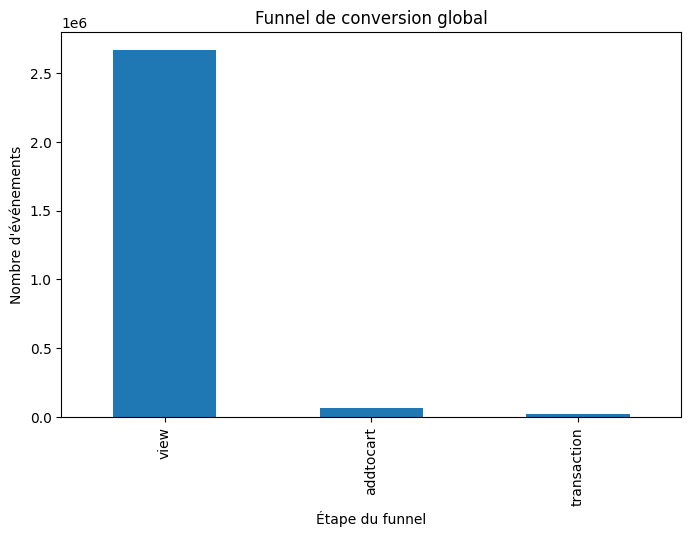

In [28]:
#Funnel global
funnel_counts = events_clean["event"].value_counts().reindex(["view", "addtocart", "transaction"])
funnel_counts
funnel_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Funnel de conversion global")
plt.xlabel("Étape du funnel")
plt.ylabel("Nombre d'événements")


In [29]:
#Taux de conversion
views = funnel_counts.get("view", 0)
atc = funnel_counts.get("addtocart", 0)
trx = funnel_counts.get("transaction", 0)

conversion_view_to_atc = atc / views if views else np.nan
conversion_atc_to_trx = trx / atc if atc else np.nan
conversion_view_to_trx = trx / views if views else np.nan

conversion_view_to_atc, conversion_atc_to_trx, conversion_view_to_trx
# --- IGNORE ---



(np.float64(0.02602247784793973),
 np.float64(0.3239052674089886),
 np.float64(0.008428817645981402))

<Axes: xlabel='date'>

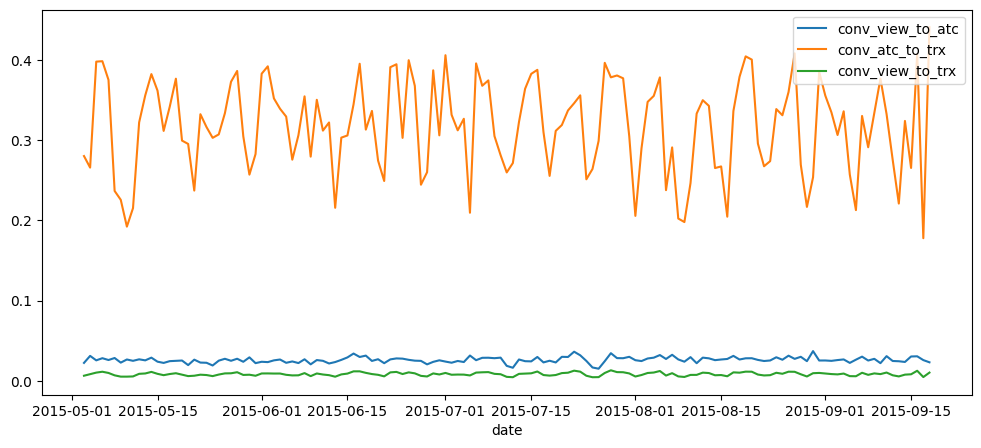

In [30]:
#Funnel par jour
daily_funnel = (
    events_clean
    .groupby("date")[["is_view", "is_addtocart", "is_transaction"]]
    .sum()
    .reset_index()
)

daily_funnel["conv_view_to_atc"] = daily_funnel["is_addtocart"] / daily_funnel["is_view"].replace(0, np.nan)
daily_funnel["conv_atc_to_trx"] = daily_funnel["is_transaction"] / daily_funnel["is_addtocart"].replace(0, np.nan)
daily_funnel["conv_view_to_trx"] = daily_funnel["is_transaction"] / daily_funnel["is_view"].replace(0, np.nan)

daily_funnel.head()
daily_funnel.plot(
    x="date",
    y=["conv_view_to_atc", "conv_atc_to_trx", "conv_view_to_trx"],
    figsize=(12, 5)
)

In [31]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_RAW = Path("../data/row")   
DATA_CLEAN = Path("data/clean")
DATA_CLEAN.mkdir(parents=True, exist_ok=True)

# Lecture brute
events = pd.read_csv(DATA_RAW / "events.csv", low_memory=False)


# Nettoyage / structuration
events["timestamp"] = pd.to_datetime(events["timestamp"], unit="ms", errors="coerce")
events = events.dropna(subset=["timestamp", "visitorid", "itemid", "event"])

events["date"] = events["timestamp"].dt.date
events["hour"] = events["timestamp"].dt.hour
events["day_of_week"] = events["timestamp"].dt.day_name()

events["is_view"] = (events["event"] == "view").astype(int)
events["is_addtocart"] = (events["event"] == "addtocart").astype(int)
events["is_transaction"] = (events["event"] == "transaction").astype(int)

# Export clean
events.to_csv(DATA_CLEAN / "events_clean.csv", index=False)

print("events_clean.csv créé dans :", (DATA_CLEAN / "events_clean.csv").resolve())


events_clean.csv créé dans : C:\Users\Hp\Desktop\Projet_Data_Driven_E-commeerce\Notebook\data\clean\events_clean.csv


In [32]:
from pathlib import Path
import pandas as pd

# Racine du projet (Notebook → projet)
PROJECT_ROOT = Path.cwd().parent

DATA_CLEAN = PROJECT_ROOT / "data" / "clean"
DATA_CLEAN.mkdir(parents=True, exist_ok=True)

# Lecture des données nettoyées
print("Shape avant export :", events.shape)

# Export propre
events.to_csv(DATA_CLEAN / "events_clean.csv", index=False)

print("events_clean.csv exporté dans :",
      (DATA_CLEAN / "events_clean.csv").resolve())


Shape avant export : (2756101, 11)
events_clean.csv exporté dans : C:\Users\Hp\Desktop\Projet_Data_Driven_E-commeerce\data\clean\events_clean.csv


In [33]:
from pathlib import Path

def print_tree(path, prefix=""):
    print(prefix + path.name)
    if path.is_dir():
        for p in path.iterdir():
            print_tree(p, prefix + "  ")

print_tree(Path.cwd().parent)


Projet_Data_Driven_E-commeerce
  .env
  .git
    COMMIT_EDITMSG
    config
    description
    FETCH_HEAD
    HEAD
    hooks
      applypatch-msg.sample
      commit-msg.sample
      fsmonitor-watchman.sample
      post-update.sample
      pre-applypatch.sample
      pre-commit.sample
      pre-merge-commit.sample
      pre-push.sample
      pre-rebase.sample
      pre-receive.sample
      prepare-commit-msg.sample
      push-to-checkout.sample
      sendemail-validate.sample
      update.sample
    index
    info
      exclude
    logs
      HEAD
      refs
        heads
          main
        remotes
          origin
            HEAD
            main
    objects
      07
        850627ba69f4ef4a38f9d07cdb55ac3ece2336
      08
        fdda022045b8f0c5642c226aaec6ceb2e2b0cc
      0d
        bb10479be03e289c64c7a8cac9c4f92b5f4ea6
      13
        d97eb8b1e3d99205fca96fa98b22bd009b3237
      15
        26333ead45d014eb74ac482d460799db5ebb01
      1b
        b0e605d0a37895e9ad90cfefefba4c